# **Mestrado em Informática**
## *Aprendizagem Máquina*

# **Pós-Graduação em Data Science and Digital Transformation**

## *Análise de Dados e Aprendizagem Automática*

Mónica Vieira Martins
---------------------

># Tutorial 07 - Clustering

Um tutorial para aprender a trabalhar com k-means, usando o dataset Iris



## 1. Dados

O dataset Iris contém medições de 150 flores de 3 espécies diferentes: comprimento e largura das sépalas e das pétalas.

Neste tutorial, a anotação  sobre a espécie não vai ser usada para treinar o modelo, porque o objetivo é exemplificar a utilização de um algoritmo não supervisionado.

Todavia, essa informação vai ser guardada, para comparação no final

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import RobustScaler
np.random.seed(42)

In [2]:
iris = sns.load_dataset('iris')

In [3]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
X = iris.iloc[:, :-1]
y= iris.species   #apenas para comparação final


print("Dimensões do dataset:", X.shape)

display(X.head())
X.describe()


Dimensões do dataset: (150, 4)


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
y.value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

### Visualização de algumas combinações de dados

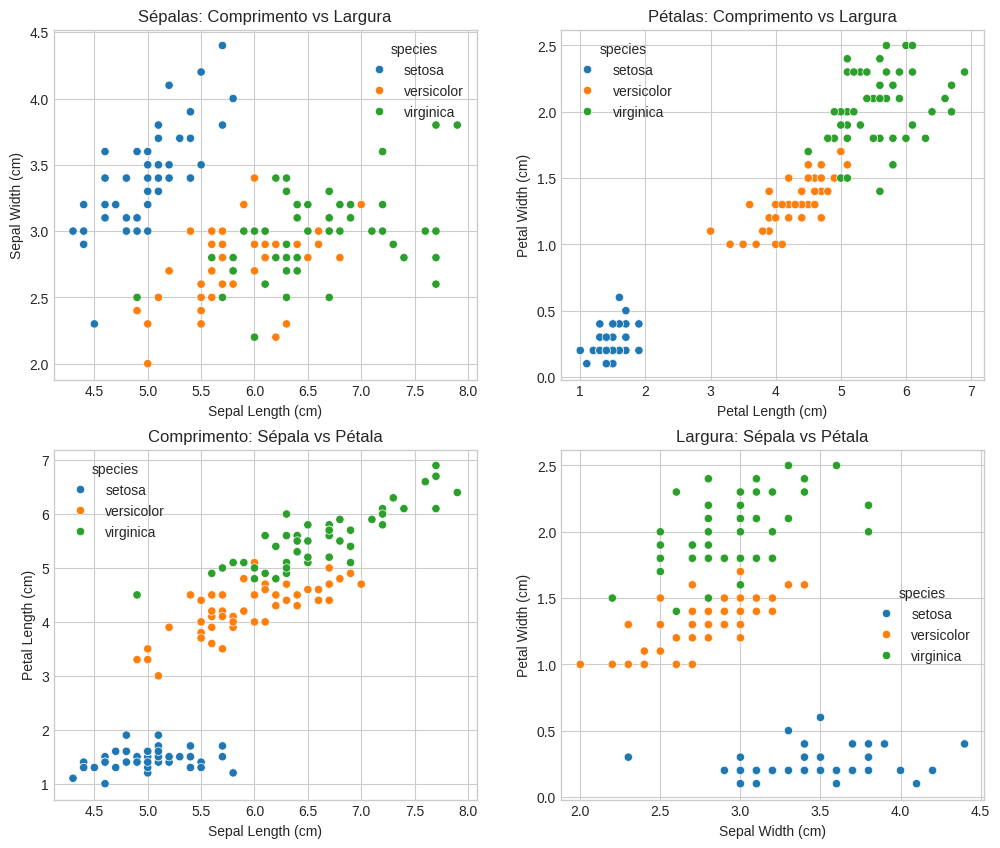

In [6]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Sepal length vs Sepal width
sns.scatterplot(data=iris,
                x='sepal_length',
                y='sepal_width',
                hue='species',
                ax=axes[0, 0])
axes[0, 0].set_xlabel('Sepal Length (cm)')
axes[0, 0].set_ylabel('Sepal Width (cm)')
axes[0, 0].set_title('Sépalas: Comprimento vs Largura')

#Petal length vs Petal width
sns.scatterplot(data = iris,
                x='petal_length',
                y='petal_width',
                hue='species',ax=axes[0, 1])
axes[0, 1].set_xlabel('Petal Length (cm)')
axes[0, 1].set_ylabel('Petal Width (cm)')
axes[0, 1].set_title('Pétalas: Comprimento vs Largura')

# Sepal length vs Petal length
sns.scatterplot(data = iris,
                x='sepal_length',
                y='petal_length',
                 hue='species',ax=axes[1, 0])
axes[1, 0].set_xlabel('Sepal Length (cm)')
axes[1, 0].set_ylabel('Petal Length (cm)')
axes[1, 0].set_title('Comprimento: Sépala vs Pétala')

# Sepal width vs Petal width
sns.scatterplot(data = iris,
                x='sepal_width',
                y='petal_width',
                hue='species',
                ax=axes[1, 1])
axes[1, 1].set_xlabel('Sepal Width (cm)')
axes[1, 1].set_ylabel('Petal Width (cm)')
axes[1, 1].set_title('Largura: Sépala vs Pétala')

plt.show()

Olhando para os gráficos, especialmente o das pétalas (canto superior direito), conseguimos identificar visualmente:
- Um grupo claramente separado (em baixo à esquerda)
- Dois grupos que parecem parcialmente sobrepostos (em cima à direita)

### Normalização dos dados

O K-Means usa **distâncias euclidianas** para atribuir pontos a clusters.
Se as variáveis tiverem escalas muito diferentes, as variáveis com valores maiores vão dominar o cálculo da distância.
Assim sendo, é necessário proceder à normalização das variáveis antes de treinar o modelo. Como em casos anteriores, vamos usar o RobustScaler.

In [8]:
# Aplicar normalização
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

## Escolha no número de clusters

A escolha do número de clusters (k) é fundamental no k-means.  
Vamos usar duas abordagens
* Método do cotovelo
* Método da silhueta

### 4.1 Método do Cotovelo

A **inércia** mede a soma das distâncias quadráticas de cada ponto ao centróide do seu cluster:

$$\text{Inércia} = \sum_{i=1}^{n} \|x_i - \mu_{c_i}\|^2$$

- Quanto menor for a inércia, mais compactos são os clusters
- A inércia diminui à medida que de aumenta k (no limite, k=n dá inércia=0)
- Procuramos o **"cotovelo"**: o ponto onde adicionar mais clusters deixa de trazer ganhos significativos

In [9]:
from sklearn.cluster import KMeans

#Calcular inércia para diferentes valores de K
k_range = range(1, 11)
inercias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)

# Mostrar os valores
print("k\tInércia")
print("-" * 20)
for k, inercia in zip(k_range, inercias):
    print(f"{k}\t{inercia:.2f}")

k	Inércia
--------------------
1	250.06
2	114.81
3	73.19
4	64.87
5	48.79
6	39.17
7	36.18
8	29.98
9	27.02
10	22.31


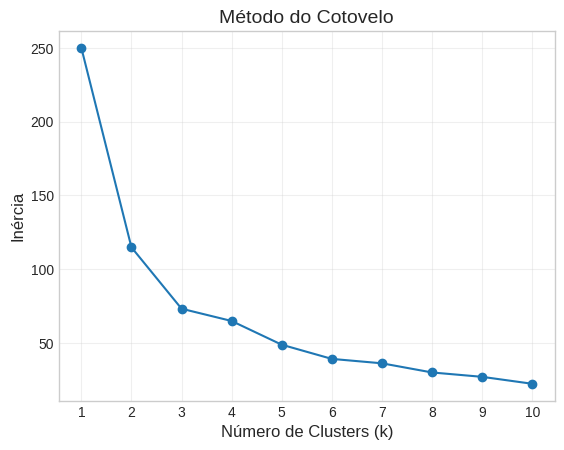

In [10]:
#Visualizar o método do cotovelo.
plt.plot(k_range, inercias, marker='o')
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inércia', fontsize=12)
plt.title('Método do Cotovelo', fontsize=14)
plt.xticks(k_range)

plt.grid(True, alpha=0.3)
plt.show()


 Observamos uma clara mudança de declive em **k=3**:
 - De k=1 para k=2 e de k=2 para k=3: grandes reduções na inércia
 - De k=3 em diante: reduções muito mais modestas

 O cotovelo sugere **k=3**.

### O método da silhueta

A **Silhueta** mede a qualidade do clustering de forma diferente. Para cada ponto, calcula:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Onde:

-  $a(i)$ = distância média aos outros pontos **do mesmo cluster** (coesão)
-  $b(i)$ = distância média aos pontos **do cluster vizinho mais próximo** (separação)

O score varia entre:
 - **+1**: clusters bem definidos e separados
 - **0**: clusters sobrepostos
 - **-1**: pontos atribuídos ao cluster errado



k	Silhueta 
-------------------------
2	0.5284
3	0.4431
4	0.3605
5	0.3414
6	0.3536
7	0.3426
8	0.3539
9	0.3317
10	0.3657


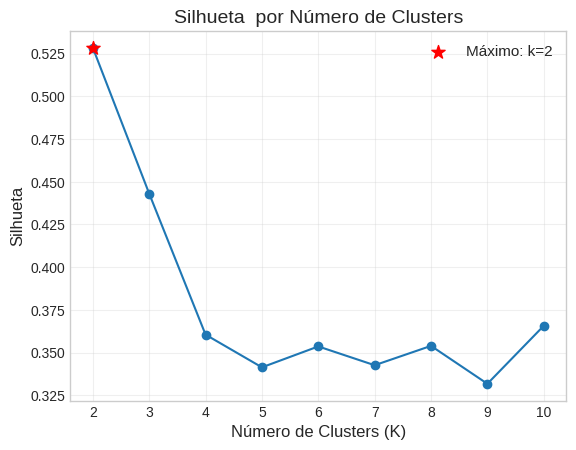

In [13]:

from sklearn.metrics import silhouette_score
# Calcular silhueta para diferentes valores de K
k_range = range(2, 11)  # Começa em 2
silhueta_scores = []

for k in k_range :
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled) #labels que resultam do clustering.
    score = silhouette_score(X_scaled, labels)
    silhueta_scores.append(score)

# Mostrar os valores
print("k\tSilhueta ")
print("-" * 25)
for k, score in zip(k_range, silhueta_scores):
    print(f"{k}\t{score:.4f}")


# Visualizar

plt.plot(k_range, silhueta_scores, marker='o')
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Silhueta', fontsize=12)
plt.title('Silhueta  por Número de Clusters', fontsize=14)
plt.xticks(k_range)

# Marcar o máximo
max_idx = np.argmax(silhueta_scores)
max_k = k_range[max_idx]
max_score = silhueta_scores[max_idx]
plt.scatter([max_k], [max_score], c='red', marker='*', s=100, zorder=3, label=f'Máximo: k={max_k}')
plt.legend(fontsize=11)

plt.grid(True, alpha=0.3)
plt.show()


O valor da Silhueta  **máximo para k=2**, embora para k=3 também tenha um valor elevado.

Isto acontece porque duas das espécies de Iris (versicolor e virginica) são bastante semelhantes,
e do ponto de vista puramente geométrico, agrupá-las num só cluster dá boa separação.
Combinando:
 - A análise visual (que sugeria 3 grupos)
 - O método do cotovelo (cotovelo claro em K=3)


Escolhemos k=3.

## Aplicar o K-Means


In [14]:
# Aplicar K-Means com K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Resultados
print("Resultados do K-Means")
print(f"Número de iterações: {kmeans.n_iter_}")
print(f"Inércia final: {kmeans.inertia_:.2f}")
print(f"\nPontos por cluster:")
for i in range(3):
    print(f"  Cluster {i}: {np.sum(labels == i)} pontos")




Resultados do K-Means
Número de iterações: 8
Inércia final: 73.18

Pontos por cluster:
  Cluster 0: 49 pontos
  Cluster 1: 52 pontos
  Cluster 2: 49 pontos


# Visualizar o resultado

In [15]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


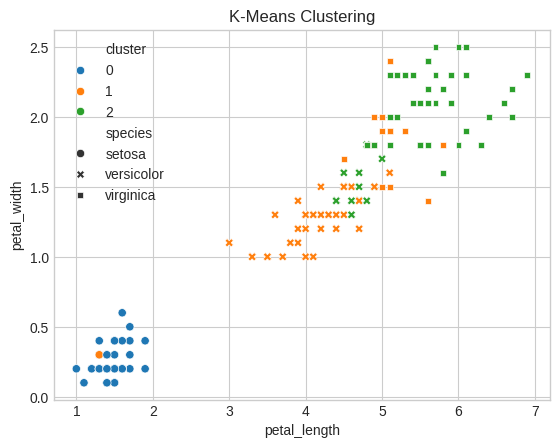

In [16]:
#adicionar o cluster ao dataframe, para visualização
iris['cluster'] = labels.astype(str)

sns.scatterplot(data=iris,
                x='petal_length',
                y='petal_width',
                hue='cluster',
                style='species')

# centróides

plt.title('K-Means Clustering')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Labels Reais')

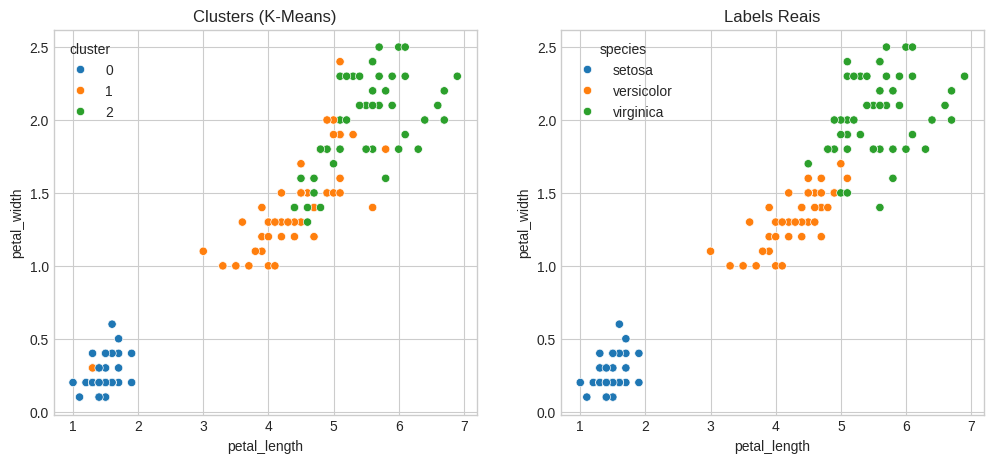

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Clusters (KMeans)
sns.scatterplot(data=iris,
                x='petal_length',
                y='petal_width',
                hue='cluster',
                ax=axes[0])
axes[0].set_title('Clusters (K-Means)')

# Labels reais
sns.scatterplot(data=iris,
                x='petal_length',
                y='petal_width',
                hue='species',
                ax=axes[1])
axes[1].set_title('Labels Reais')